## Code parameters from paper (page-11)

1) Assume MaxCut, so q=2 (Pott's formulation)
2) W: adjacency/weight matrix, shape (n, n) => Symmetric, W[i,j]=weight.
3) batch (they call it): number of replicas m. Think: m parallel restarts.
4) h: learnable “logits / local fields”, shape (batch, n, q) This is what Adam actually updates.
5) p = softmax(h, dim=2): probabilities, shape (batch, n, q). For each replica r and node i: p[r,i,0] + p[r,i,1] = 1

So each replica is a full probabilistic solution.

In [48]:
import torch
import torch.nn.functional as F
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [49]:
def random_binary_undirected_graph(n_nodes=20, edge_prob=0.2, seed=1):
    """
    Simple undirected graph:
      - No self-loops
      - No multi-edges
      - Binary edges (present/absent)
    """
    G = nx.erdos_renyi_graph(n=n_nodes, p=edge_prob, seed=seed, directed=False)
    return G
def draw_graph(G, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, with_labels=True, node_color="lightblue")
    plt.show()

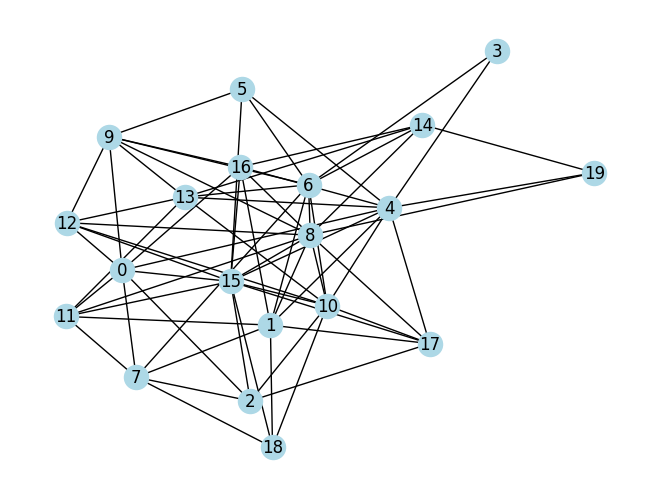

In [50]:
# generate graph
G = random_binary_undirected_graph(n_nodes=20, edge_prob=0.3, seed=7)
draw_graph(G)

In [51]:
def graph_to_binary_adjacency(G):
    n = G.number_of_nodes()
    W = np.zeros((n, n), dtype=np.float32)
    for u, v in G.edges():
        W[u, v] = 1.0
        W[v, u] = 1.0
    return W

In [52]:
# adjacency matrix
W = graph_to_binary_adjacency(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

W shape: (20, 20)
Unique values in W: [0. 1.]


In [53]:
# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- graph ---
W = torch.tensor(W, dtype=torch.float32).to(device)

# --- hyperparameters ---
batch = 64
q = 2
n = W.shape[0]
beta_range = torch.linspace(0.5, 20.0, steps=200).to(device)

# --- learnable fields ---
h = torch.nn.Parameter(torch.rand(batch, n, q, device=device))

In [54]:
def cut(W, p):
    # W: (n,n), p: (batch,n,q)
    return ((W @ p) * (1 - p)).sum((1, 2))

def S(p, eps=1e-12):
    p = p.clamp_min(eps)
    return -(p * p.log()).sum(2).sum(1)

def argmax_cut(W, p):
    config = p.argmax(dim=2)  # (batch,n)
    s = F.one_hot(config, num_classes=p.shape[2]).float()
    return config, cut(W, s) / 2

In [55]:
def solve_maxcut(W, batch=64, lr=0.01, steps=200):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # graph
    W = torch.tensor(W, dtype=torch.float32).to(device)
    n = W.shape[0]
    q = 2  # MaxCut

    # replicas / fields
    h = torch.nn.Parameter(torch.rand(batch, n, q, device=device))
    optimizer = torch.optim.Adam([h], lr=lr)

    beta_range = torch.linspace(0.5, 20.0, steps=steps).to(device)

    for beta in beta_range:
        p = torch.softmax(h, dim=2)
        Fval = -cut(W, p) - S(p) / beta

        optimizer.zero_grad()
        Fval.backward(torch.ones_like(Fval))
        optimizer.step()

    return argmax_cut(W, torch.softmax(h, dim=2))

In [56]:
# solve
config, cutvals = solve_maxcut(W, batch=64, steps=300)

# pick best replica
best = cutvals.argmax()
best_config = config[best]
best_cut = cutvals[best].item()

print("Best cut value:", best_cut)
print("Best partition:", best_config.cpu().numpy())

Best cut value: 49.0
Best partition: [1 1 0 1 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1]


/var/folders/hs/wzcwdwgd39lbf4_c_gqzw19r0000gn/T/ipykernel_61020/1093951572.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  W = torch.tensor(W, dtype=torch.float32).to(device)


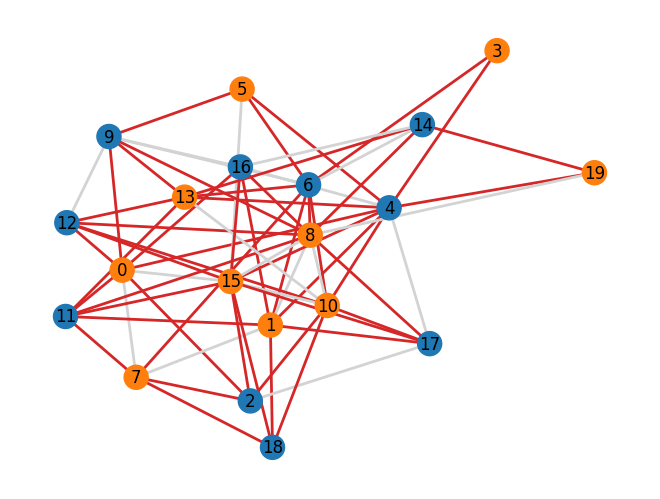

In [58]:
x = best_config.cpu().numpy()

def draw_cut(G, x, seed=42):
    pos = nx.spring_layout(G, seed=seed)

    # node colors: 0 -> one color, 1 -> another
    node_colors = ["tab:blue" if x[i] == 0 else "tab:orange" for i in G.nodes()]

    # edge colors: cut edges in red, others in light gray
    edge_colors = []
    for u, v in G.edges():
        edge_colors.append("tab:red" if x[u] != x[v] else "lightgray")

    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors, width=2)
    plt.show()
draw_cut(G,x)